# PCOS GNN Training Pipeline — Notebook 2

**Phases:** 4 Graph Construction · 5 Dataset Split · 6 Model Training

**Thesis:** A Machine Learning Framework for PCOS Subtype Discovery and Classification

**Dataset:** Kerala PCOS Cleaned Dataset (n = 541)

---

**Instructions:**
1. Run **Cell 1** (installation) then **restart the kernel**
2. Run all cells in order (Cells 2–10)
3. Change `MODEL_NAME` in Cell 9 to switch models: GCN | GAT | GRAPHSAGE | MPNN | GIN

**Plots display inline** in this notebook and are also saved to `/kaggle/working/`.

## Cell 1 — Installation

In [1]:
import subprocess, sys

def pip_install(pkg, find_links=None):
    cmd = [sys.executable, '-m', 'pip', 'install', pkg, '-q']
    if find_links:
        cmd += ['-f', find_links]
    subprocess.run(cmd, check=True)

#print(f"PyTorch : {torch_ver}")
#print(f"CUDA    : {cuda_tag}")
#print(f"Wheel   : {pyg_url}")

pip_install('torch_geometric')
pip_install('imbalanced-learn')

print("\nInstallation complete. Restart the kernel now, then run Cell 2 onwards.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.3 MB/s eta 0:00:00

Installation complete. Restart the kernel now, then run Cell 2 onwards.


## Cell 2 — Imports, Seed & Configuration

In [2]:
%matplotlib inline
# CELL 2 — IMPORTS, SEED, CONFIGURATION

get_ipython().run_line_magic('matplotlib', 'inline')

import os, gc, random, warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display as ipy_display

import torch
import torch.nn.functional as F
from torch.nn import (Linear, Sequential, BatchNorm1d, ReLU)

import torch_geometric
from torch_geometric.data  import Data
from torch_geometric.nn    import (GCNConv, GATConv, SAGEConv,
                                    GINConv, NNConv)
from gensim.models          import Word2Vec   # custom Node2Vec
from torch_geometric.utils import coalesce

from sklearn.model_selection   import StratifiedKFold, train_test_split
from sklearn.preprocessing     import StandardScaler
from sklearn.metrics.pairwise  import cosine_similarity
from sklearn.manifold           import TSNE
from sklearn.metrics            import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, roc_auc_score, average_precision_score,
    cohen_kappa_score, confusion_matrix, fowlkes_mallows_score,
    normalized_mutual_info_score, roc_curve, precision_recall_curve,
    det_curve
)

from imblearn.over_sampling import SMOTE
import networkx as nx

# ── version info ─────────────────────────────────────────────────
print(f"PyTorch           : {torch.__version__}")
print(f"PyTorch Geometric : {torch_geometric.__version__}")
print(f"CUDA available    : {torch.cuda.is_available()}")

# ── global seed ──────────────────────────────────────────────────
GLOBAL_SEED = 42

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(GLOBAL_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device            : {DEVICE}")

# ── configuration ────────────────────────────────────────────────
CONFIG = {
    'DATA_PATH'    : ('/kaggle/input/datasets/monamehrun/'
                      'pcos-cleaned-dataset/pcos_cleaned.csv'),
    'TARGET_COL'   : 'PCOS',
    'OUTPUT_DIR'   : '/kaggle/working/',
    'TEST_SIZE'    : 0.20,
    'N_FOLDS'      : 10,
    'SEED'         : GLOBAL_SEED,
    'K_NEIGHBOURS' : 10,
    'N2V_DIM'      : 64,
    'N2V_WALK_LEN' : 20,
    'N2V_CONTEXT'  : 10,
    'N2V_WALKS'    : 10,
    'N2V_EPOCHS'   : 50,
    'N2V_LR'       : 0.01,
    'HIDDEN_DIM'   : 64,
    'DROPOUT'      : 0.3,
    'EPOCHS'       : 200,
    'LR'           : 0.001,
    'WEIGHT_DECAY' : 1e-4,
    'PATIENCE'     : 30,
}

print("\nConfiguration loaded.")

PyTorch           : 2.10.0+cu128
PyTorch Geometric : 2.7.0
CUDA available    : True
Device            : cuda

Configuration loaded.


## Cell 3 — Load Data & 80/20 Stratified Split

In [3]:
# CELL 3 — LOAD DATA AND 80/20 STRATIFIED SPLIT

df = pd.read_csv(CONFIG['DATA_PATH'])
print(f"Loaded  : {df.shape[0]} rows x {df.shape[1]} columns")

y             = df[CONFIG['TARGET_COL']].values.astype(np.int64)
X             = df.drop(columns=[CONFIG['TARGET_COL']]).values.astype(np.float32)
feature_names = df.drop(columns=[CONFIG['TARGET_COL']]).columns.tolist()

print(f"Features: {X.shape[1]}")
print(f"PCOS=0  : {(y==0).sum()}  ({(y==0).mean()*100:.1f}%)")
print(f"PCOS=1  : {(y==1).sum()}  ({(y==1).mean()*100:.1f}%)")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = CONFIG['TEST_SIZE'],
    stratify     = y,
    random_state = CONFIG['SEED']
)

print(f"\nTraining pool  : {len(X_train)} "
      f"(PCOS=0: {(y_train==0).sum()}  PCOS=1: {(y_train==1).sum()})")
print(f"Test set sealed: {len(X_test)}  "
      f"(PCOS=0: {(y_test==0).sum()}   PCOS=1: {(y_test==1).sum()})")

test_df = pd.DataFrame(X_test, columns=feature_names)
test_df.insert(0, 'PCOS', y_test)
test_df.to_csv(os.path.join(CONFIG['OUTPUT_DIR'], 'pcos_test_set.csv'),
               index=False)
print("\nTest set saved -> pcos_test_set.csv  [SEALED: Notebook 3 only]")

Loaded  : 541 rows x 49 columns
Features: 48
PCOS=0  : 364  (67.3%)
PCOS=1  : 177  (32.7%)

Training pool  : 432 (PCOS=0: 291  PCOS=1: 141)
Test set sealed: 109  (PCOS=0: 73   PCOS=1: 36)

Test set saved -> pcos_test_set.csv  [SEALED: Notebook 3 only]


## Cell 4 — Graph Utility Functions (custom Node2Vec)

In [4]:
# CELL 4 — GRAPH UTILITY FUNCTIONS

# ── 4A: k-NN COSINE SIMILARITY GRAPH ─────────────────────────────

def build_knn_graph(features_scaled: np.ndarray, k: int = 10):
    """
    Build a weighted undirected k-NN patient similarity graph.
    features_scaled : [n, d] already StandardScaler-transformed
    Returns edge_index [2,E] LongTensor and edge_weight [E] FloatTensor.
    """
    n   = len(features_scaled)
    sim = cosine_similarity(features_scaled)
    np.fill_diagonal(sim, -2.0)

    src, dst, wts = [], [], []
    for i in range(n):
        top_k = np.argpartition(sim[i], -k)[-k:]
        for j in top_k:
            w = float(max(0.0, sim[i][j]))
            src += [i, j];  dst += [j, i];  wts += [w, w]

    ei = torch.tensor([src, dst], dtype=torch.long)
    ew = torch.tensor(wts,        dtype=torch.float)
    ei, ew = coalesce(ei, ew, num_nodes=n, reduce='max')
    return ei, ew


# ── 4B: ADD SYNTHETIC NODES ───────────────────────────────────────

def add_synthetic_nodes(ei, ew, X_real_sc, X_syn_sc, k=10):
    """Add SMOTE synthetic nodes; connect to real training nodes only."""
    n_real, n_syn = len(X_real_sc), len(X_syn_sc)
    if n_syn == 0:
        return ei, ew
    sim = cosine_similarity(X_syn_sc, X_real_sc)
    src, dst, wts = [], [], []
    for i in range(n_syn):
        s = n_real + i
        for j in np.argpartition(sim[i], -k)[-k:]:
            w = float(max(0.0, sim[i][j]))
            src += [s, j];  dst += [j, s];  wts += [w, w]
    new_ei = torch.tensor([src, dst], dtype=torch.long)
    new_ew = torch.tensor(wts,        dtype=torch.float)
    aug_ei = torch.cat([ei, new_ei], dim=1)
    aug_ew = torch.cat([ew, new_ew])
    aug_ei, aug_ew = coalesce(aug_ei, aug_ew,
                               num_nodes=n_real + n_syn, reduce='max')
    return aug_ei, aug_ew


# ── 4C: ADD VALIDATION NODES ──────────────────────────────────────

def add_val_nodes(ei_aug, ew_aug, X_real_sc, X_val_sc,
                   k=10, n_train_aug=None):
    """Insert val nodes; connect to real training nodes only."""
    n_real = len(X_real_sc)
    n_val  = len(X_val_sc)
    if n_train_aug is None:
        n_train_aug = n_real
    sim = cosine_similarity(X_val_sc, X_real_sc)
    src, dst, wts = [], [], []
    for i in range(n_val):
        v = n_train_aug + i
        for j in np.argpartition(sim[i], -k)[-k:]:
            w = float(max(0.0, sim[i][j]))
            src += [v, j];  dst += [j, v];  wts += [w, w]
    new_ei  = torch.tensor([src, dst], dtype=torch.long)
    new_ew  = torch.tensor(wts,        dtype=torch.float)
    comb_ei = torch.cat([ei_aug, new_ei],  dim=1)
    comb_ew = torch.cat([ew_aug, new_ew])
    return comb_ei, comb_ew


# ── 4D: NODE2VEC ──────────────────────────────────────────────────

def _random_walks(edge_index, num_nodes: int,
                   walk_length: int, walks_per_node: int, seed: int = 42):
    """Generate random walks from edge_index adjacency list."""
    import random as _random
    _random.seed(seed)
    adj = [[] for _ in range(num_nodes)]
    ei  = edge_index.cpu().numpy()
    for s, d in zip(ei[0], ei[1]):
        adj[int(s)].append(int(d))
    walks = []
    nodes = list(range(num_nodes))
    for _ in range(walks_per_node):
        _random.shuffle(nodes)
        for start in nodes:
            walk = [start]
            for _ in range(walk_length - 1):
                curr = walk[-1]
                nbrs = adj[curr]
                if nbrs:
                    walk.append(_random.choice(nbrs))
                else:
                    break
            walks.append([str(n) for n in walk])
    return walks


def train_node2vec(edge_index, num_nodes: int, cfg: dict, device):
    """
    Custom DeepWalk-style Node2Vec using gensim Word2Vec on random walks.
    Equivalent to PyG Node2Vec (p=q=1). No extra packages needed.
    gensim is pre-installed on Kaggle.
    Returns numpy array [num_nodes, N2V_DIM].
    """
    walks = _random_walks(
        edge_index, num_nodes,
        walk_length    = cfg['N2V_WALK_LEN'],
        walks_per_node = cfg['N2V_WALKS'],
        seed           = cfg['SEED'],
    )
    w2v = Word2Vec(
        sentences   = walks,
        vector_size = cfg['N2V_DIM'],
        window      = cfg['N2V_CONTEXT'],
        min_count   = 0,
        sg          = 1,          # skip-gram
        workers     = 1,          # deterministic
        seed        = cfg['SEED'],
        epochs      = cfg['N2V_EPOCHS'],
    )
    emb = np.zeros((num_nodes, cfg['N2V_DIM']), dtype=np.float32)
    for idx in range(num_nodes):
        key = str(idx)
        if key in w2v.wv:
            emb[idx] = w2v.wv[key]
    return emb



def inductive_n2v(X_new_sc, X_train_sc, n2v_train, k=10):
    """Inductive Node2Vec: weighted-average of k nearest neighbours."""
    sim = cosine_similarity(X_new_sc, X_train_sc)
    out = np.zeros((len(X_new_sc), n2v_train.shape[1]), dtype=np.float32)
    for i in range(len(X_new_sc)):
        top_k = np.argpartition(sim[i], -k)[-k:]
        w     = np.maximum(sim[i][top_k], 0.0)
        wsum  = w.sum()
        w     = w / wsum if wsum > 1e-9 else np.ones(k) / k
        out[i] = (n2v_train[top_k] * w[:, None]).sum(axis=0)
    return out


# ── 4E: SMOTE ─────────────────────────────────────────────────────

def apply_smote(X, y, seed=42):
    """SMOTE on training nodes only. Never applied to val or test."""
    smote        = SMOTE(random_state=seed, k_neighbors=5)
    X_res, y_res = smote.fit_resample(X, y)
    n_syn = len(X_res) - len(X)
    print(f"    SMOTE: +{n_syn} synthetic PCOS+ "
          f"-> balance {(y_res==0).sum()} neg : {(y_res==1).sum()} pos")
    return X_res, y_res

print("Graph utility functions loaded.")

Graph utility functions loaded.


## Cell 5 — Model Definitions (GCN | GAT | GraphSAGE | MPNN | GIN)

In [5]:
# CELL 5 — MODEL DEFINITIONS
# GCN | GAT | GraphSAGE | MPNN | GIN
# All share the same forward(x, edge_index, edge_weight) signature.

class GCN(torch.nn.Module):
    """Graph Convolutional Network -- Kipf & Welling 2017."""
    def __init__(self, in_ch, hidden_ch, out_ch, dropout=0.3):
        super().__init__()
        self.c1   = GCNConv(in_ch, hidden_ch)
        self.c2   = GCNConv(hidden_ch, hidden_ch)
        self.lin  = Linear(hidden_ch, out_ch)
        self.drop = dropout

    def forward(self, x, edge_index, edge_weight=None):
        x = F.relu(self.c1(x, edge_index, edge_weight))
        x = F.dropout(x, self.drop, self.training)
        x = F.relu(self.c2(x, edge_index, edge_weight))
        x = F.dropout(x, self.drop, self.training)
        return self.lin(x)

    def embed(self, x, edge_index, edge_weight=None):
        x = F.relu(self.c1(x, edge_index, edge_weight))
        return self.c2(x, edge_index, edge_weight)

class GAT(torch.nn.Module):
    """Graph Attention Network -- Velickovic et al. 2018.
    Single-head variant for compatibility with this PyG version."""
    def __init__(self, in_ch, hidden_ch, out_ch, dropout=0.3):
        super().__init__()
        in_ch     = int(in_ch)
        hidden_ch = int(hidden_ch)
        out_ch    = int(out_ch)
        self.c1   = GATConv(in_ch, hidden_ch,
                             heads=1, concat=False,
                             dropout=dropout, add_self_loops=False)
        self.c2   = GATConv(hidden_ch, hidden_ch,
                             heads=1, concat=False,
                             dropout=dropout, add_self_loops=False)
        self.lin  = Linear(hidden_ch, out_ch)
        self.drop = dropout

    def forward(self, x, edge_index, edge_weight=None):
        x = F.dropout(x, self.drop, self.training)
        x = F.elu(self.c1(x, edge_index))
        x = F.dropout(x, self.drop, self.training)
        x = F.elu(self.c2(x, edge_index))
        return self.lin(x)

    def embed(self, x, edge_index, edge_weight=None):
        x = F.elu(self.c1(x, edge_index))
        return self.c2(x, edge_index)


class GraphSAGE(torch.nn.Module):
    """GraphSAGE -- Hamilton et al. 2017."""
    def __init__(self, in_ch, hidden_ch, out_ch, dropout=0.3):
        super().__init__()
        self.c1   = SAGEConv(in_ch, hidden_ch)
        self.c2   = SAGEConv(hidden_ch, hidden_ch)
        self.lin  = Linear(hidden_ch, out_ch)
        self.drop = dropout

    def forward(self, x, edge_index, edge_weight=None):
        x = F.relu(self.c1(x, edge_index))
        x = F.dropout(x, self.drop, self.training)
        x = F.relu(self.c2(x, edge_index))
        x = F.dropout(x, self.drop, self.training)
        return self.lin(x)

    def embed(self, x, edge_index, edge_weight=None):
        x = F.relu(self.c1(x, edge_index))
        return self.c2(x, edge_index)


class MPNN(torch.nn.Module):
    """Message Passing Neural Network using NNConv."""
    def __init__(self, in_ch, hidden_ch, out_ch, dropout=0.3):
        super().__init__()
        self.c1   = NNConv(in_ch, hidden_ch,
                            Linear(1, in_ch * hidden_ch), aggr='mean')
        self.c2   = NNConv(hidden_ch, hidden_ch,
                            Linear(1, hidden_ch * hidden_ch), aggr='mean')
        self.lin  = Linear(hidden_ch, out_ch)
        self.drop = dropout

    def _ea(self, ew, ei, device):
        if ew is not None:
            return ew.unsqueeze(-1)
        return torch.ones(ei.size(1), 1, device=device)

    def forward(self, x, edge_index, edge_weight=None):
        ea = self._ea(edge_weight, edge_index, x.device)
        x  = F.relu(self.c1(x, edge_index, ea))
        x  = F.dropout(x, self.drop, self.training)
        x  = F.relu(self.c2(x, edge_index, ea))
        x  = F.dropout(x, self.drop, self.training)
        return self.lin(x)

    def embed(self, x, edge_index, edge_weight=None):
        ea = self._ea(edge_weight, edge_index, x.device)
        x  = F.relu(self.c1(x, edge_index, ea))
        return self.c2(x, edge_index, ea)


class GIN(torch.nn.Module):
    """Graph Isomorphism Network -- Xu et al. 2019."""
    def __init__(self, in_ch, hidden_ch, out_ch, dropout=0.3):
        super().__init__()
        self.c1 = GINConv(Sequential(
            Linear(in_ch, hidden_ch), BatchNorm1d(hidden_ch),
            ReLU(), Linear(hidden_ch, hidden_ch)
        ), train_eps=True)
        self.c2 = GINConv(Sequential(
            Linear(hidden_ch, hidden_ch), BatchNorm1d(hidden_ch),
            ReLU(), Linear(hidden_ch, hidden_ch)
        ), train_eps=True)
        self.lin  = Linear(hidden_ch, out_ch)
        self.drop = dropout

    def forward(self, x, edge_index, edge_weight=None):
        x = F.relu(self.c1(x, edge_index))
        x = F.dropout(x, self.drop, self.training)
        x = F.relu(self.c2(x, edge_index))
        x = F.dropout(x, self.drop, self.training)
        return self.lin(x)

    def embed(self, x, edge_index, edge_weight=None):
        x = F.relu(self.c1(x, edge_index))
        return self.c2(x, edge_index)


MODEL_REGISTRY = {
    'GCN'       : GCN,
    'GAT'       : GAT,
    'GRAPHSAGE' : GraphSAGE,
    'MPNN'      : MPNN,
    'GIN'       : GIN,
}

def get_model(name, in_ch, hidden_ch, out_ch, dropout):
    name = name.upper()
    if name not in MODEL_REGISTRY:
        raise ValueError(f"Unknown model '{name}'. "
                         f"Options: {list(MODEL_REGISTRY)}")
    if name == 'GAT':
        return GAT(int(in_ch), int(hidden_ch), int(out_ch), dropout)
    return MODEL_REGISTRY[name](int(in_ch), int(hidden_ch), int(out_ch), dropout)

print("Models loaded: GCN | GAT | GraphSAGE | MPNN | GIN")

Models loaded: GCN | GAT | GraphSAGE | MPNN | GIN


## Cell 6 — Training, Evaluation & Metrics

In [6]:
# CELL 6 — TRAINING, EVALUATION, METRICS

def train_one_epoch(model, data, optimizer, criterion):
    model.train()
    optimizer.zero_grad()
    out  = model(data.x, data.edge_index, data.edge_weight)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    if torch.isnan(loss):
        return float('nan')
    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def evaluate_model(model, data, mask):
    model.eval()
    out   = model(data.x, data.edge_index, data.edge_weight)
    probs = torch.softmax(out[mask], dim=1)[:, 1].cpu().numpy()
    preds = out[mask].argmax(dim=1).cpu().numpy()
    true  = data.y[mask].cpu().numpy()
    return preds, probs, true


def compute_metrics(true, preds, probs):
    cm           = confusion_matrix(true, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    try:    auroc = roc_auc_score(true, probs)
    except: auroc = 0.0
    return {
        'accuracy'    : accuracy_score(true, preds),
        'precision'   : precision_score(true, preds, zero_division=0),
        'recall'      : recall_score(true, preds, zero_division=0),
        'f1'          : f1_score(true, preds, zero_division=0),
        'mcc'         : matthews_corrcoef(true, preds),
        'auroc'       : auroc,
        'auprc'       : average_precision_score(true, probs),
        'sensitivity' : sens,
        'specificity' : spec,
        'kappa'       : cohen_kappa_score(true, preds),
        'fmi'         : fowlkes_mallows_score(true, preds),
        'nmi'         : normalized_mutual_info_score(true, preds),
    }, (int(tn), int(fp), int(fn), int(tp))

print("Train / eval / metric functions loaded.")

Train / eval / metric functions loaded.


## Cell 7 — Visualisation Functions

In [7]:
# CELL 7 — VISUALISATION FUNCTIONS
# All required plots:
#   graph topology, Node2Vec t-SNE, degree distribution,
#   loss curve, training curve, per-fold metrics,
#   confusion matrix, ROC, PR, DET, Lift, Precision-Threshold,
#   per-class metrics table.

# ── graph topology (spring layout) ───────────────────────────────

def plot_patient_graph(edge_index, y_labels, title, save_name):
    G = nx.Graph()
    n = len(y_labels)
    G.add_nodes_from(range(n))
    G.add_edges_from(edge_index.t().tolist())
    print("    Computing spring layout (~20 s)...")
    set_seed(GLOBAL_SEED)
    pos    = nx.spring_layout(G, seed=GLOBAL_SEED,
                               iterations=30, k=1.5 / np.sqrt(n))
    colors = ['#3a86ff' if l == 0 else '#ff595e' for l in y_labels]
    fig, ax = plt.subplots(figsize=(10, 10))
    nx.draw_networkx_edges(G, pos, alpha=0.12,
                            edge_color='gray', width=0.4, ax=ax)
    nx.draw_networkx_nodes(G, pos, node_color=colors,
                            node_size=18, ax=ax)
    legend = [mpatches.Patch(facecolor='#3a86ff', label='No PCOS'),
               mpatches.Patch(facecolor='#ff595e', label='PCOS')]
    ax.legend(handles=legend, fontsize=11, loc='upper right')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    path = os.path.join(CONFIG['OUTPUT_DIR'], save_name)
    plt.savefig(path, dpi=150, bbox_inches='tight')
    ipy_display(fig); plt.close(fig)
    print(f"    Saved -> {save_name}")


# ── Node2Vec t-SNE ────────────────────────────────────────────────

def plot_n2v_tsne(embeddings, labels, title, save_name):
    set_seed(GLOBAL_SEED)
    coords = TSNE(n_components=2, random_state=GLOBAL_SEED,
                   perplexity=min(30, len(embeddings) // 4)
                   ).fit_transform(embeddings)
    fig, ax = plt.subplots(figsize=(8, 6))
    for lbl, col, nm in [(0, '#3a86ff', 'No PCOS'), (1, '#ff595e', 'PCOS')]:
        m = labels == lbl
        ax.scatter(coords[m, 0], coords[m, 1],
                    c=col, s=18, alpha=0.75, label=nm, edgecolors='none')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    plt.tight_layout()
    path = os.path.join(CONFIG['OUTPUT_DIR'], save_name)
    plt.savefig(path, dpi=150, bbox_inches='tight')
    ipy_display(fig); plt.close(fig)


# ── degree distribution ───────────────────────────────────────────

def plot_degree_distribution(edge_index, n_nodes, title, save_name):
    deg = np.bincount(edge_index[0].numpy(), minlength=n_nodes)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(deg, bins=30, color='#3a86ff', alpha=0.85, edgecolor='white')
    ax.axvline(deg.mean(), color='#ff595e', ls='--', lw=2,
                label=f'Mean = {deg.mean():.1f}')
    ax.set_xlabel('Node Degree'); ax.set_ylabel('Count')
    ax.set_title(title, fontweight='bold'); ax.legend()
    plt.tight_layout()
    path = os.path.join(CONFIG['OUTPUT_DIR'], save_name)
    plt.savefig(path, dpi=150, bbox_inches='tight')
    ipy_display(fig); plt.close(fig)


# ── loss curve + training (AUROC) curve ──────────────────────────

def plot_training_curves(fold_curves, model_name):
    """
    fold_curves : list of dicts, each with keys 'losses' and 'aurocs'.
    Plots mean +/- std band across folds for:
      - training loss vs epoch
      - validation AUROC vs epoch
    """
    # Pad to equal length (early stopping means different lengths)
    max_len = max(len(fc['losses']) for fc in fold_curves)

    def pad(arr):
        return arr + [arr[-1]] * (max_len - len(arr))

    losses = np.array([pad(fc['losses']) for fc in fold_curves])
    aurocs = np.array([pad(fc['aurocs']) for fc in fold_curves])
    epochs = np.arange(1, max_len + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss curve
    mean_l = losses.mean(axis=0)
    std_l  = losses.std(axis=0)
    ax1.plot(epochs, mean_l, color='#3a86ff', lw=2, label='Mean loss')
    ax1.fill_between(epochs, mean_l - std_l, mean_l + std_l,
                      alpha=0.2, color='#3a86ff', label='+/- 1 std')
    for i, fc in enumerate(fold_curves):
        ax1.plot(range(1, len(fc['losses']) + 1), fc['losses'],
                  alpha=0.15, color='gray', lw=0.8)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
    ax1.set_title(f'{model_name} -- Training Loss Curve', fontweight='bold')
    ax1.legend()

    # AUROC training curve
    mean_a = aurocs.mean(axis=0)
    std_a  = aurocs.std(axis=0)
    ax2.plot(epochs, mean_a, color='#ff595e', lw=2, label='Mean val AUROC')
    ax2.fill_between(epochs, mean_a - std_a, mean_a + std_a,
                      alpha=0.2, color='#ff595e', label='+/- 1 std')
    ax2.axhline(0.69, color='#06d6a0', ls='--', lw=1.5,
                 label='Supervisor threshold (0.69)')
    for i, fc in enumerate(fold_curves):
        ax2.plot(range(1, len(fc['aurocs']) + 1), fc['aurocs'],
                  alpha=0.15, color='gray', lw=0.8)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Validation AUROC')
    ax2.set_title(f'{model_name} -- Training Curve (Val AUROC)', fontweight='bold')
    ax2.set_ylim(0, 1.02); ax2.legend()

    plt.tight_layout()
    path = os.path.join(CONFIG['OUTPUT_DIR'], f'{model_name}_training_curves.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    ipy_display(fig); plt.close(fig)


# ── per-fold metric bar chart ─────────────────────────────────────

def plot_fold_metrics(fold_metrics, model_name):
    keys   = ['accuracy', 'mcc', 'auroc', 'f1', 'sensitivity', 'specificity']
    colors = ['#3a86ff', '#ff595e', '#06d6a0', '#ffbe0b', '#8338ec', '#fb5607']
    n_fold = len(fold_metrics)
    x, bw  = np.arange(n_fold), 0.13

    fig, ax = plt.subplots(figsize=(14, 5))
    for i, (k, c) in enumerate(zip(keys, colors)):
        vals   = [fm[k] for fm in fold_metrics]
        offset = (i - len(keys) / 2 + 0.5) * bw
        ax.bar(x + offset, vals, bw, label=k.upper(),
                color=c, alpha=0.82, edgecolor='white', linewidth=0.5)
        ax.axhline(np.mean(vals), color=c, ls='--', lw=1, alpha=0.55)

    ax.set_xticks(x)
    ax.set_xticklabels([f'Fold {i+1}' for i in range(n_fold)])
    ax.set_ylabel('Score'); ax.set_ylim(0, 1.08)
    ax.set_title(f'{model_name} -- Per-Fold Metrics (dashed = mean)',
                  fontweight='bold')
    ax.legend(fontsize=8, ncol=6, loc='lower right')
    plt.tight_layout()
    path = os.path.join(CONFIG['OUTPUT_DIR'], f'{model_name}_fold_metrics.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    ipy_display(fig); plt.close(fig)


# ── confusion matrix ──────────────────────────────────────────────

def plot_confusion_matrix(all_true, all_preds, model_name):
    cm = confusion_matrix(all_true, all_preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                 xticklabels=['Pred: No PCOS', 'Pred: PCOS'],
                 yticklabels=['True: No PCOS', 'True: PCOS'],
                 linewidths=0.5)
    ax.set_title(f'{model_name} -- Aggregated Confusion Matrix\n'
                  f'(10-Fold CV, n={len(all_true)}  '
                  f'TP={tp} FP={fp} TN={tn} FN={fn})',
                  fontweight='bold')
    plt.tight_layout()
    path = os.path.join(CONFIG['OUTPUT_DIR'], f'{model_name}_confusion.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    ipy_display(fig); plt.close(fig)


# ── ROC + PR curves ───────────────────────────────────────────────

def plot_roc_pr(all_true, all_probs, model_name):
    fpr, tpr, _  = roc_curve(all_true, all_probs)
    pre, rec, _  = precision_recall_curve(all_true, all_probs)
    auroc_v = roc_auc_score(all_true, all_probs)
    auprc_v = average_precision_score(all_true, all_probs)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    ax1.plot(fpr, tpr, '#3a86ff', lw=2,
              label=f'ROC  (AUROC = {auroc_v:.4f})')
    ax1.plot([0, 1], [0, 1], 'k--', lw=1)
    ax1.axvline(x=0.3, color='gray', ls=':', lw=1, alpha=0.5)
    ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
    ax1.set_title(f'{model_name} -- ROC Curve', fontweight='bold')
    ax1.legend(); ax1.set_xlim(0, 1); ax1.set_ylim(0, 1.02)

    base = all_true.mean()
    ax2.plot(rec, pre, '#ff595e', lw=2,
              label=f'PR   (AUPRC = {auprc_v:.4f})')
    ax2.axhline(base, color='gray', ls='--', lw=1,
                 label=f'Baseline ({base:.3f})')
    ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
    ax2.set_title(f'{model_name} -- Precision-Recall Curve', fontweight='bold')
    ax2.legend(); ax2.set_xlim(0, 1); ax2.set_ylim(0, 1.02)

    plt.tight_layout()
    path = os.path.join(CONFIG['OUTPUT_DIR'], f'{model_name}_roc_pr.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    ipy_display(fig); plt.close(fig)


# ── DET curve ────────────────────────────────────────────────────

def plot_det_curve(all_true, all_probs, model_name):
    """
    Detection Error Tradeoff curve.
    Plots False Negative Rate vs False Positive Rate on linear scale.
    A perfect model sits at the origin (0, 0).
    """
    fpr, fnr, _ = det_curve(all_true, all_probs)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr, fnr, color='#8338ec', lw=2, label=model_name)
    ax.plot([0, 1], [1, 0], 'k--', lw=1, alpha=0.5, label='Random')
    ax.scatter([0], [0], color='#06d6a0', s=80, zorder=5,
                label='Perfect (0, 0)')
    ax.set_xlabel('False Positive Rate  (1 - Specificity)')
    ax.set_ylabel('False Negative Rate  (1 - Sensitivity)')
    ax.set_title(f'{model_name} -- DET Curve\n'
                  f'(Detection Error Tradeoff)', fontweight='bold')
    ax.legend(); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    plt.tight_layout()
    path = os.path.join(CONFIG['OUTPUT_DIR'], f'{model_name}_det_curve.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    ipy_display(fig); plt.close(fig)


# ── Lift curve ────────────────────────────────────────────────────

def plot_lift_curve(all_true, all_probs, model_name):
    """
    Lift curve: shows how much better the model is vs random
    at capturing PCOS-positive cases.
    X-axis: proportion of patients selected (sorted by prob desc)
    Y-axis: cumulative lift = (% positives captured / % patients selected)
             relative to random (baseline lift = 1.0)
    """
    all_true  = np.array(all_true)
    all_probs = np.array(all_probs)
    n         = len(all_true)
    pos_rate  = all_true.mean()

    order         = np.argsort(all_probs)[::-1]
    y_sorted      = all_true[order]
    cum_pos       = np.cumsum(y_sorted)
    cum_pct       = np.arange(1, n + 1) / n
    lift          = (cum_pos / np.arange(1, n + 1)) / pos_rate

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Lift chart
    ax1.plot(cum_pct * 100, lift, color='#3a86ff', lw=2, label='Model lift')
    ax1.axhline(1.0, color='gray', ls='--', lw=1.5, label='Baseline (random)')
    ax1.set_xlabel('% of Patients Selected (sorted by predicted probability)')
    ax1.set_ylabel('Cumulative Lift')
    ax1.set_title(f'{model_name} -- Lift Curve', fontweight='bold')
    ax1.legend(); ax1.set_xlim(0, 100); ax1.set_ylim(0)

    # Cumulative gains chart (companion to lift)
    cum_gain = cum_pos / all_true.sum() * 100
    ax2.plot(cum_pct * 100, cum_gain,
              color='#ff595e', lw=2, label='Model gains')
    ax2.plot([0, 100], [0, 100],
              'k--', lw=1, label='Random (baseline)')
    ax2.plot([0, pos_rate * 100, 100], [0, 100, 100],
              color='#06d6a0', ls=':', lw=1.5, label='Perfect model')
    ax2.set_xlabel('% of Patients Selected')
    ax2.set_ylabel('% of PCOS-Positive Cases Captured')
    ax2.set_title(f'{model_name} -- Cumulative Gains Chart', fontweight='bold')
    ax2.legend(); ax2.set_xlim(0, 100); ax2.set_ylim(0, 105)

    plt.tight_layout()
    path = os.path.join(CONFIG['OUTPUT_DIR'], f'{model_name}_lift_gains.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    ipy_display(fig); plt.close(fig)


# ── Precision-Threshold curve ─────────────────────────────────────

def plot_precision_threshold(all_true, all_probs, model_name):
    """
    Precision, Recall, and F1 vs classification threshold.
    Helps choose the operating threshold for clinical deployment.
    """
    prec, rec, thresholds = precision_recall_curve(all_true, all_probs)
    # precision_recall_curve returns one extra value; align
    thresholds = np.append(thresholds, 1.0)
    f1_scores  = np.where((prec + rec) > 0,
                           2 * prec * rec / (prec + rec), 0)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(thresholds, prec, color='#3a86ff', lw=2, label='Precision')
    ax.plot(thresholds, rec,  color='#ff595e', lw=2, label='Recall')
    ax.plot(thresholds, f1_scores, color='#06d6a0', lw=2, label='F1')

    best_f1_idx = np.argmax(f1_scores)
    ax.axvline(thresholds[best_f1_idx], color='#ffbe0b', ls='--', lw=1.5,
                label=f'Best F1 threshold = {thresholds[best_f1_idx]:.3f}')
    ax.axvline(0.5, color='gray', ls=':', lw=1, label='Default threshold (0.5)')

    ax.set_xlabel('Classification Threshold')
    ax.set_ylabel('Score')
    ax.set_title(f'{model_name} -- Precision / Recall / F1 vs Threshold',
                  fontweight='bold')
    ax.legend(); ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    plt.tight_layout()
    path = os.path.join(CONFIG['OUTPUT_DIR'],
                         f'{model_name}_precision_threshold.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    ipy_display(fig); plt.close(fig)


# ── per-class metrics table ───────────────────────────────────────

def print_per_class_metrics(all_true, all_preds, all_probs, model_name):
    """
    Prints a full per-class breakdown:
    Class 0 (No PCOS) and Class 1 (PCOS) each get their own
    precision, recall, F1, and support.
    Also prints the complete metric table with flags.
    """
    cm           = confusion_matrix(all_true, all_preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    p0 = tn / (tn + fn) if (tn + fn) > 0 else 0.0   # precision for class 0
    r0 = tn / (tn + fp) if (tn + fp) > 0 else 0.0   # recall    for class 0
    f0 = 2*p0*r0/(p0+r0) if (p0+r0) > 0 else 0.0

    p1 = tp / (tp + fp) if (tp + fp) > 0 else 0.0   # precision for class 1
    r1 = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # recall    for class 1
    f1v= 2*p1*r1/(p1+r1) if (p1+r1) > 0 else 0.0

    print(f"\n{'='*62}")
    print(f"  {model_name} -- Per-Class Metrics")
    print(f"{'='*62}")
    print(f"  {'Class':<20} {'Precision':>10} {'Recall':>10} "
          f"{'F1':>10} {'Support':>10}")
    print(f"  {'-'*60}")
    print(f"  {'0 (No PCOS)':<20} {p0:>10.4f} {r0:>10.4f} "
          f"{f0:>10.4f} {int(tn+fp):>10}")
    print(f"  {'1 (PCOS)':<20} {p1:>10.4f} {r1:>10.4f} "
          f"{f1v:>10.4f} {int(tp+fn):>10}")
    print(f"  {'='*62}")
    print(f"  TP={tp}  FP={fp}  TN={tn}  FN={fn}")
    print(f"  {'='*62}")


# ── results table ────────────────────────────────────────────────

def print_results_table(fold_metrics, model_name):
    metrics = list(fold_metrics[0].keys())
    W       = 10
    sep     = '-' * (8 + W * len(metrics))
    print(f"\n{'='*len(sep)}")
    print(f"  {model_name}  --  10-Fold Cross-Validation Results")
    print(f"{'='*len(sep)}")
    hdr = f"{'Fold':>6}  " + ''.join(f"{m.upper():>{W}}" for m in metrics)
    print(hdr); print(sep)
    for i, fm in enumerate(fold_metrics):
        print(f"  {i+1:>4}  " +
              ''.join(f"{fm[m]:>{W}.4f}" for m in metrics))
    print(sep)
    print(f"  {'MEAN':>4}  " +
          ''.join(f"{np.mean([fm[m] for fm in fold_metrics]):>{W}.4f}"
                  for m in metrics))
    print(f"  {'STD':>4}  " +
          ''.join(f"{np.std([fm[m] for fm in fold_metrics]):>{W}.4f}"
                  for m in metrics))
    print(f"{'='*len(sep)}")

print("All visualisation functions loaded.")

All visualisation functions loaded.


## Cell 8 — Main 10-Fold CV Runner

In [8]:
# CELL 8 — MAIN 10-FOLD CV RUNNER

def run_cv(model_name: str,
           X_pool:     np.ndarray,
           y_pool:     np.ndarray,
           cfg:        dict,
           device):
    """
    10-fold inductive cross-validation.

    Per fold:
      1. Stratified split -> train / val nodes
      2. StandardScaler fit on train, transform val
      3. Build k-NN cosine graph from train nodes
      4. Train Node2Vec -> structural embeddings
      5. Concatenate scaled (48) + N2V (64) = 112-dim features
      6. SMOTE on train nodes in 112-dim space
      7. Add synthetic nodes to graph
      8. Inductive Node2Vec embeddings for val nodes
      9. Add val nodes to graph (real train only)
     10. PyG Data object with train_mask / val_mask
     11. GNN training: class-weighted CE + early stopping on AUROC
         -- stores epoch losses and val AUROCs for curve plots
     12. Evaluate on val nodes

    Returns
    -------
    fold_metrics : list of metric dicts
    all_true     : aggregated labels
    all_probs    : aggregated probabilities
    all_preds    : aggregated predictions
    fold_curves  : list of {'losses': [...], 'aurocs': [...]}
    """
    n_clinical   = X_pool.shape[1]
    in_channels  = n_clinical + cfg['N2V_DIM']   # 48 + 64 = 112
    hidden_ch    = cfg['HIDDEN_DIM']
    out_channels = 2

    skf = StratifiedKFold(n_splits=cfg['N_FOLDS'],
                           shuffle=True, random_state=cfg['SEED'])

    fold_metrics = []
    fold_curves  = []
    all_true, all_probs, all_preds = [], [], []
    viz_done = False

    for fold_idx, (tr_idx, va_idx) in \
            enumerate(skf.split(X_pool, y_pool)):

        print(f"\n{'='*62}")
        print(f"  FOLD {fold_idx+1}/{cfg['N_FOLDS']}  |  "
              f"train={len(tr_idx)}  val={len(va_idx)}")
        print(f"{'='*62}")

        X_tr, y_tr = X_pool[tr_idx], y_pool[tr_idx]
        X_va, y_va = X_pool[va_idx], y_pool[va_idx]
        print(f"  Train PCOS+: {y_tr.sum()}  |  Val PCOS+: {y_va.sum()}")

        # scale
        scaler  = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr)
        X_va_sc = scaler.transform(X_va)

        # graph
        print("  [3] Building training graph...", end=' ', flush=True)
        ei_tr, ew_tr = build_knn_graph(X_tr_sc, k=cfg['K_NEIGHBOURS'])
        n_real = len(X_tr_sc)
        print(f"nodes={n_real}  edges={ei_tr.size(1)}")

        # node2vec
        print("  [4] Training Node2Vec...", end=' ', flush=True)
        n2v_tr = train_node2vec(ei_tr, n_real, cfg, device)
        print(f"shape={n2v_tr.shape}")

        X_tr_full = np.concatenate([X_tr_sc, n2v_tr], axis=1)

        # smote
        print("  [6] Applying SMOTE...")
        X_tr_sm, y_tr_sm = apply_smote(X_tr_full, y_tr, cfg['SEED'])
        n_syn       = len(X_tr_sm) - n_real
        n_train_aug = len(X_tr_sm)

        # synthetic nodes
        if n_syn > 0:
            X_syn_clin = X_tr_sm[n_real:, :n_clinical]
            ei_aug, ew_aug = add_synthetic_nodes(
                ei_tr, ew_tr, X_tr_sc, X_syn_clin,
                k=cfg['K_NEIGHBOURS'])
        else:
            ei_aug, ew_aug = ei_tr, ew_tr

        # inductive n2v for val
        print("  [8] Inductive Node2Vec for val...", end=' ', flush=True)
        n2v_va    = inductive_n2v(X_va_sc, X_tr_sc, n2v_tr,
                                   k=cfg['K_NEIGHBOURS'])
        X_va_full = np.concatenate([X_va_sc, n2v_va], axis=1)
        print("done")

        # add val nodes
        ei_eval, ew_eval = add_val_nodes(
            ei_aug, ew_aug, X_tr_sc, X_va_sc,
            k=cfg['K_NEIGHBOURS'], n_train_aug=n_train_aug)

        # fold 1 visualisations
        if not viz_done:
            print("  [VIZ] Graph + t-SNE plots (fold 1)...")
            plot_patient_graph(
                ei_tr.cpu(), y_tr,
                title=f'Patient Similarity Graph -- {model_name} (Fold 1)',
                save_name=f'{model_name}_graph_fold1.png')
            plot_n2v_tsne(
                n2v_tr, y_tr,
                title=f'Node2Vec Embeddings (t-SNE) -- {model_name} (Fold 1)',
                save_name=f'{model_name}_n2v_tsne.png')
            plot_degree_distribution(
                ei_tr.cpu(), n_real,
                title=f'Degree Distribution -- {model_name} Training Graph (Fold 1)',
                save_name=f'{model_name}_degree_dist.png')
            viz_done = True

        # PyG data object
        X_all = np.concatenate([X_tr_sm, X_va_full], axis=0)
        y_all = np.concatenate([y_tr_sm, y_va])
        n_all = len(X_all)

        train_mask           = torch.zeros(n_all, dtype=torch.bool)
        train_mask[:n_train_aug] = True
        val_mask             = torch.zeros(n_all, dtype=torch.bool)
        val_mask[n_train_aug:]   = True

        data = Data(
            x           = torch.tensor(X_all, dtype=torch.float),
            edge_index  = ei_eval,
            edge_weight = ew_eval,
            y           = torch.tensor(y_all, dtype=torch.long),
            train_mask  = train_mask,
            val_mask    = val_mask,
        ).to(device)

        # class weights
        n_neg = float((y_tr_sm == 0).sum())
        n_pos = float((y_tr_sm == 1).sum())
        cw    = torch.tensor([1.0, n_neg / n_pos],
                              dtype=torch.float).to(device)
        criterion = torch.nn.CrossEntropyLoss(weight=cw)

        # model + optimiser
        set_seed(cfg['SEED'] + fold_idx)
        model = get_model(model_name, in_channels, hidden_ch,
                           out_channels, cfg['DROPOUT']).to(device)
        optimizer = torch.optim.Adam(model.parameters(),
                                      lr=cfg['LR'],
                                      weight_decay=cfg['WEIGHT_DECAY'])
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=15, min_lr=1e-6)

        # training loop -- store epoch data for curve plots
        best_auroc, patience_ct, best_w = 0.0, 0, None
        epoch_losses, epoch_aurocs = [], []

        for epoch in range(1, cfg['EPOCHS'] + 1):
            loss = train_one_epoch(model, data, optimizer, criterion)
            if loss != loss:
                print(f"    NaN loss at epoch {epoch}. Stopping fold.")
                break

            preds_e, probs_e, true_e = evaluate_model(
                model, data, data.val_mask)
            try:    ep_auroc = roc_auc_score(true_e, probs_e)
            except: ep_auroc = 0.0

            epoch_losses.append(loss)
            epoch_aurocs.append(ep_auroc)
            scheduler.step(ep_auroc)

            if ep_auroc > best_auroc + 1e-4:
                best_auroc  = ep_auroc
                patience_ct = 0
                best_w = {k: v.clone()
                           for k, v in model.state_dict().items()}
            else:
                patience_ct += 1

            if patience_ct >= cfg['PATIENCE']:
                print(f"    Early stop  epoch {epoch}  |  "
                      f"best AUROC = {best_auroc:.4f}")
                break

            if epoch % 50 == 0:
                print(f"    Epoch {epoch:3d}  |  loss={loss:.4f}  |  "
                      f"val AUROC={ep_auroc:.4f}")

        fold_curves.append({'losses': epoch_losses,
                             'aurocs': epoch_aurocs})

        if best_w is not None:
            model.load_state_dict(best_w)

        preds_f, probs_f, true_f = evaluate_model(
            model, data, data.val_mask)
        metrics_f, (tn, fp, fn, tp) = compute_metrics(
            true_f, preds_f, probs_f)
        fold_metrics.append(metrics_f)
        all_true.extend(true_f.tolist())
        all_probs.extend(probs_f.tolist())
        all_preds.extend(preds_f.tolist())

        print(f"\n  Fold {fold_idx+1} Results:")
        print(f"    Accuracy  {metrics_f['accuracy']:.4f}  |  "
              f"MCC      {metrics_f['mcc']:.4f}")
        print(f"    AUROC     {metrics_f['auroc']:.4f}  |  "
              f"AUPRC    {metrics_f['auprc']:.4f}")
        print(f"    F1        {metrics_f['f1']:.4f}  |  "
              f"Kappa    {metrics_f['kappa']:.4f}")
        print(f"    Sens      {metrics_f['sensitivity']:.4f}  |  "
              f"Spec     {metrics_f['specificity']:.4f}")
        print(f"    TP={tp}  FP={fp}  TN={tn}  FN={fn}")

        torch.save(model.state_dict(),
                    os.path.join(CONFIG['OUTPUT_DIR'],
                                  f'{model_name}_fold{fold_idx+1}.pt'))

        del model, data, optimizer, scheduler, criterion
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return (fold_metrics,
            np.array(all_true),
            np.array(all_probs),
            np.array(all_preds),
            fold_curves)

print("CV runner loaded.")

CV runner loaded.


## Cell 9 — EXECUTE  (change MODEL_NAME here)


##############################################################
  Model    : GRAPHSAGE
  Device   : cuda
  Folds    : 10
  Epochs   : 200  (patience=30)
  k-NN     : 10
  N2V dim  : 64
  Hidden   : 64
  Input ch : 112 (48 clinical + 64 Node2Vec)
##############################################################


  FOLD 1/10  |  train=388  val=44
  Train PCOS+: 127  |  Val PCOS+: 14
  [3] Building training graph... nodes=388  edges=4910
  [4] Training Node2Vec... shape=(388, 64)
  [6] Applying SMOTE...
    SMOTE: +134 synthetic PCOS+ -> balance 261 neg : 261 pos
  [8] Inductive Node2Vec for val... done
  [VIZ] Graph + t-SNE plots (fold 1)...
    Computing spring layout (~20 s)...


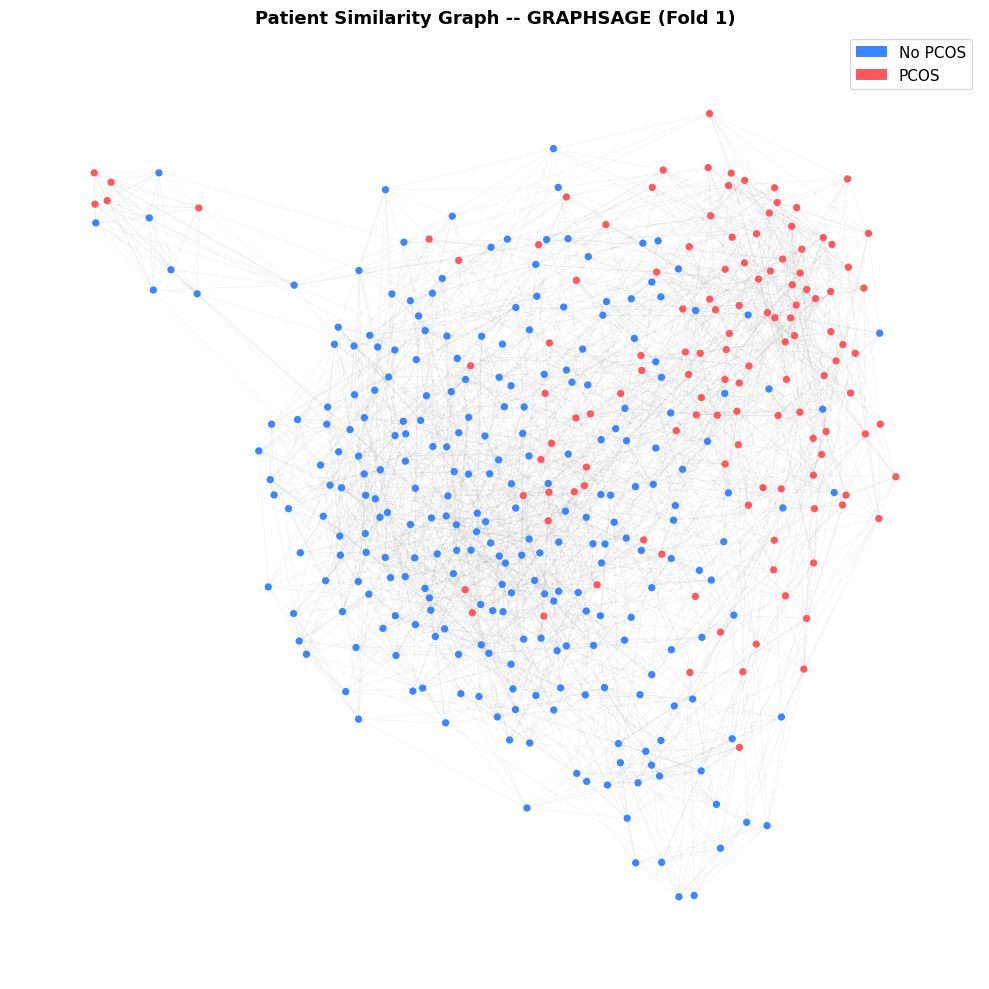

    Saved -> GRAPHSAGE_graph_fold1.png


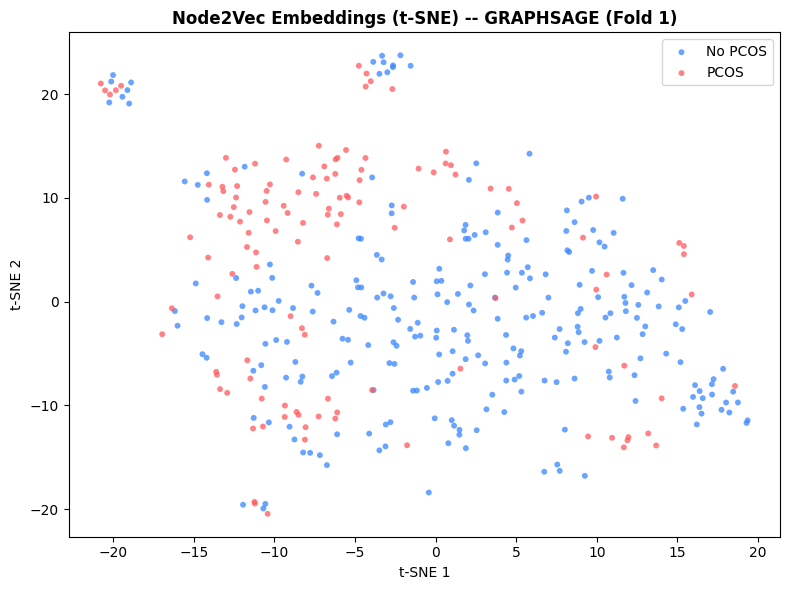

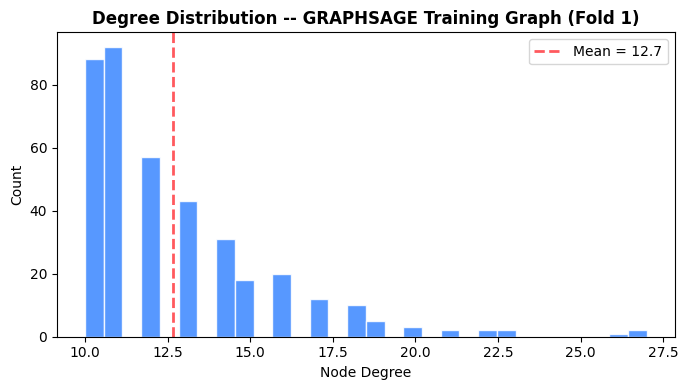

    Early stop  epoch 33  |  best AUROC = 0.8786

  Fold 1 Results:
    Accuracy  0.8409  |  MCC      0.6271
    AUROC     0.8786  |  AUPRC    0.8097
    F1        0.7407  |  Kappa    0.6262
    Sens      0.7143  |  Spec     0.9000
    TP=10  FP=3  TN=27  FN=4

  FOLD 2/10  |  train=388  val=44
  Train PCOS+: 126  |  Val PCOS+: 15
  [3] Building training graph... nodes=388  edges=4890
  [4] Training Node2Vec... shape=(388, 64)
  [6] Applying SMOTE...
    SMOTE: +136 synthetic PCOS+ -> balance 262 neg : 262 pos
  [8] Inductive Node2Vec for val... done
    Epoch  50  |  loss=0.1674  |  val AUROC=0.8989
    Epoch 100  |  loss=0.0433  |  val AUROC=0.9103
    Early stop  epoch 129  |  best AUROC = 0.9126

  Fold 2 Results:
    Accuracy  0.8409  |  MCC      0.6362
    AUROC     0.9126  |  AUPRC    0.8757
    F1        0.7407  |  Kappa    0.6280
    Sens      0.6667  |  Spec     0.9310
    TP=10  FP=2  TN=27  FN=5

  FOLD 3/10  |  train=389  val=43
  Train PCOS+: 127  |  Val PCOS+: 14
  [3] B

In [9]:
# CELL 9 — EXECUTE
# Change MODEL_NAME to run each model sequentially.
# Options: GCN | GAT | GRAPHSAGE | MPNN | GIN

MODEL_NAME = 'GRAPHSAGE'     # <- CHANGE THIS TO SWITCH MODELS

print(f"\n{'#'*62}")
print(f"  Model    : {MODEL_NAME}")
print(f"  Device   : {DEVICE}")
print(f"  Folds    : {CONFIG['N_FOLDS']}")
print(f"  Epochs   : {CONFIG['EPOCHS']}  (patience={CONFIG['PATIENCE']})")
print(f"  k-NN     : {CONFIG['K_NEIGHBOURS']}")
print(f"  N2V dim  : {CONFIG['N2V_DIM']}")
print(f"  Hidden   : {CONFIG['HIDDEN_DIM']}")
print(f"  Input ch : {X_train.shape[1] + CONFIG['N2V_DIM']} "
      f"(48 clinical + 64 Node2Vec)")
print(f"{'#'*62}\n")

set_seed(CONFIG['SEED'])

fold_metrics, all_true, all_probs, all_preds, fold_curves = run_cv(
    model_name = MODEL_NAME,
    X_pool     = X_train,
    y_pool     = y_train,
    cfg        = CONFIG,
    device     = DEVICE,
)

## Cell 10 — Results & All Visualisations


  GRAPHSAGE  --  10-Fold Cross-Validation Results
  Fold    ACCURACY PRECISION    RECALL        F1       MCC     AUROC     AUPRCSENSITIVITYSPECIFICITY     KAPPA       FMI       NMI
--------------------------------------------------------------------------------------------------------------------------------
     1      0.8409    0.7692    0.7143    0.7407    0.6271    0.8786    0.8097    0.7143    0.9000    0.6262    0.7578    0.3164
     2      0.8409    0.8333    0.6667    0.7407    0.6362    0.9126    0.8757    0.6667    0.9310    0.6280    0.7595    0.3316
     3      0.9535    0.8750    1.0000    0.9333    0.9026    1.0000    1.0000    1.0000    0.9310    0.8979    0.9156    0.7603
     4      0.7442    0.6000    0.6429    0.6207    0.4286    0.8202    0.7529    0.6429    0.7931    0.4281    0.6409    0.1420
     5      0.8605    0.8333    0.7143    0.7692    0.6742    0.9335    0.9015    0.7143    0.9310    0.6701    0.7845    0.3729
     6      0.9302    0.8667    0.9286    0.

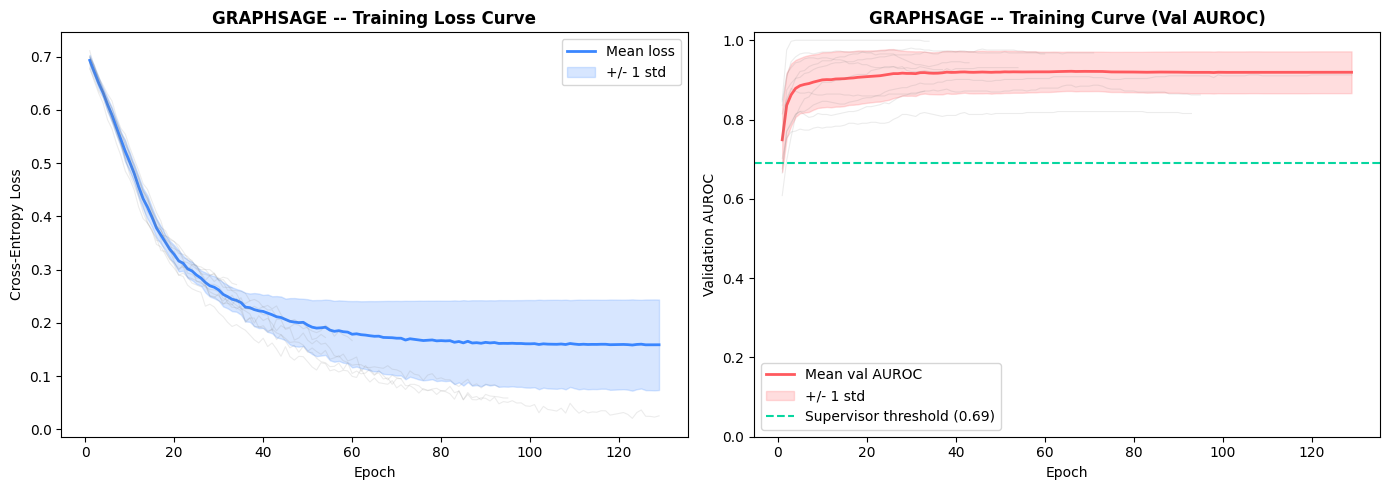

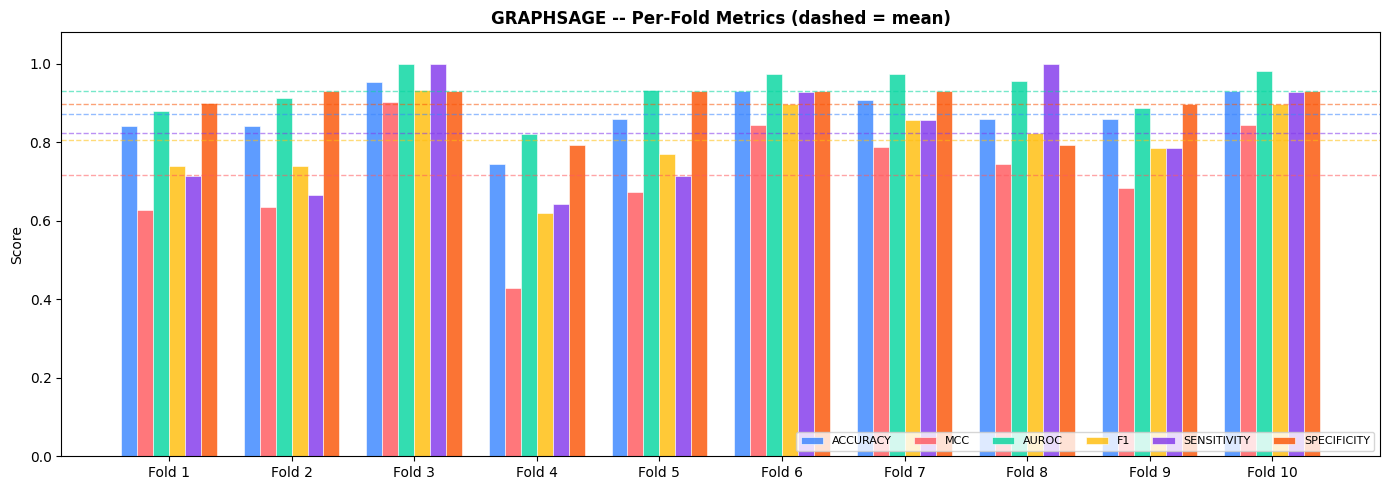

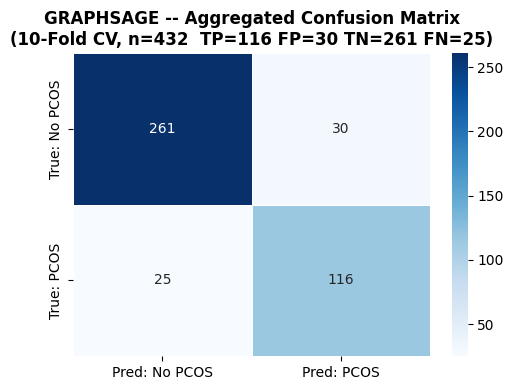

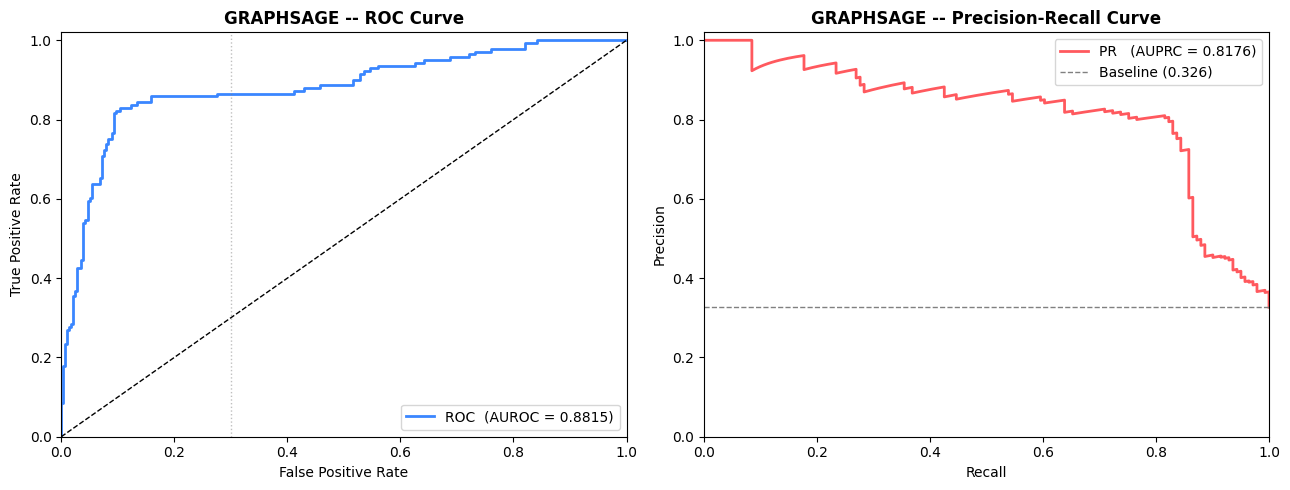

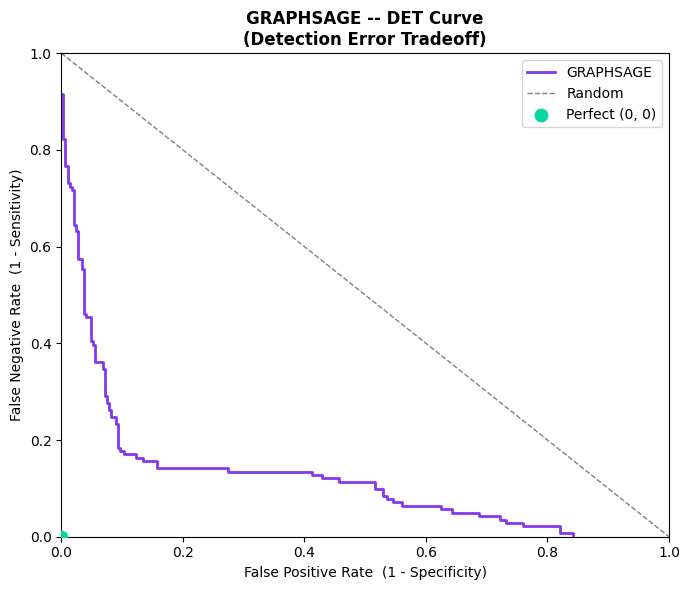

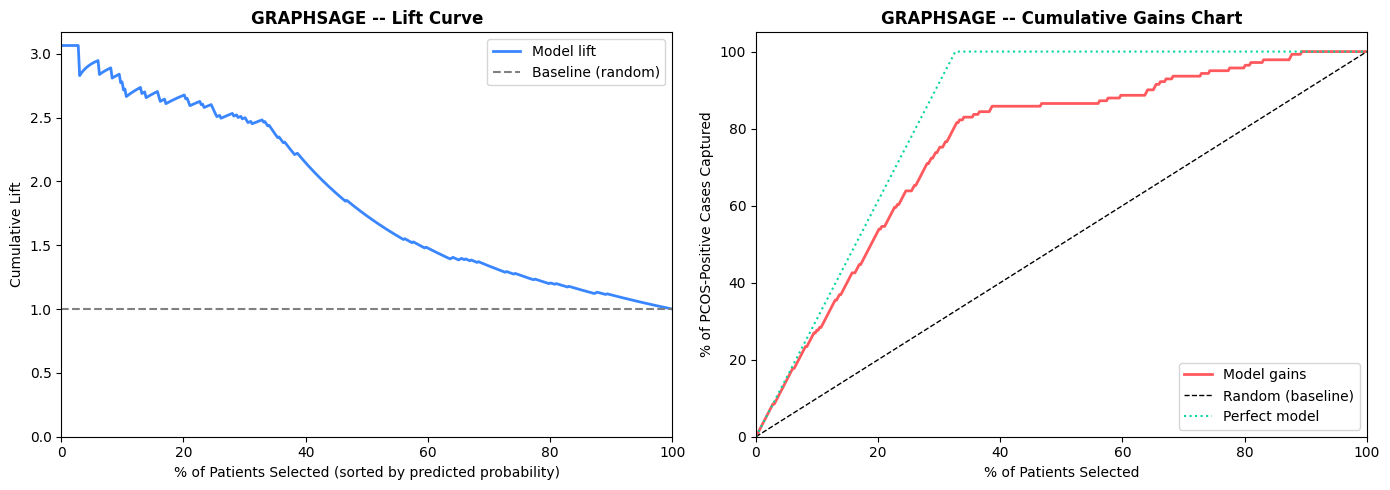

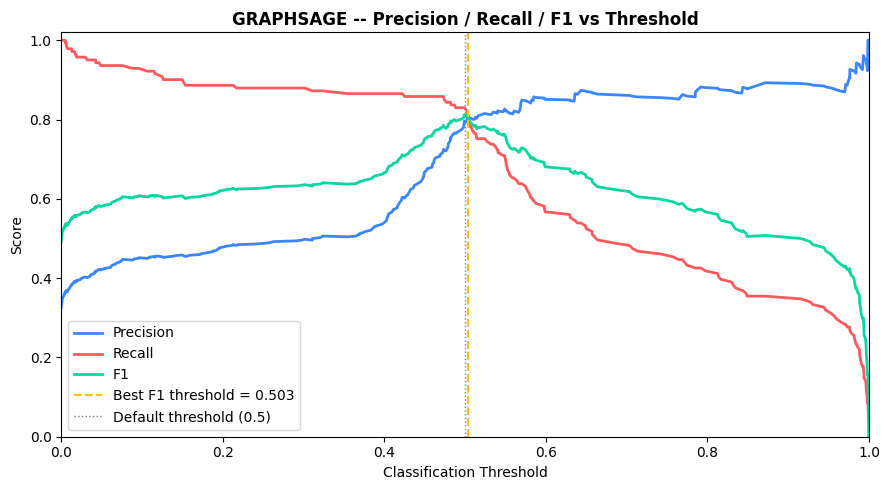


Results saved -> /kaggle/working/GRAPHSAGE_cv_results.csv

  GRAPHSAGE  --  FINAL AVERAGED METRICS
  ACCURACY       0.8728 +/- 0.0608
  PRECISION      0.7987 +/- 0.0889
  RECALL         0.8238 +/- 0.1366
  F1             0.8064 +/- 0.0944
  MCC            0.7175 +/- 0.1390  <- KEY METRIC
  AUROC          0.9313 +/- 0.0564  <- THRESHOLD MET (>=0.69)
  AUPRC          0.8944 +/- 0.0820
  SENSITIVITY    0.8238 +/- 0.1366
  SPECIFICITY    0.8969 +/- 0.0563
  KAPPA          0.7123 +/- 0.1386
  FMI            0.7998 +/- 0.0803
  NMI            0.4577 +/- 0.1825

All plots saved to /kaggle/working/
Fold weights: GRAPHSAGE_fold1.pt ... GRAPHSAGE_fold10.pt

Change MODEL_NAME in Cell 9 and re-run Cells 9-10 for the next model.


In [10]:
# CELL 10 — RESULTS AND ALL VISUALISATIONS

all_true  = np.array(all_true)
all_probs = np.array(all_probs)
all_preds = np.array(all_preds)

# ── results table ─────────────────────────────────────────────
print_results_table(fold_metrics, MODEL_NAME)

# ── per-class breakdown ───────────────────────────────────────
print_per_class_metrics(all_true, all_preds, all_probs, MODEL_NAME)

# ── training curves (loss + AUROC vs epoch) ───────────────────
plot_training_curves(fold_curves, MODEL_NAME)

# ── per-fold metric bar chart ─────────────────────────────────
plot_fold_metrics(fold_metrics, MODEL_NAME)

# ── confusion matrix ──────────────────────────────────────────
plot_confusion_matrix(all_true, all_preds, MODEL_NAME)

# ── ROC + PR curves ───────────────────────────────────────────
plot_roc_pr(all_true, all_probs, MODEL_NAME)

# ── DET curve ─────────────────────────────────────────────────
plot_det_curve(all_true, all_probs, MODEL_NAME)

# ── Lift + Cumulative Gains ───────────────────────────────────
plot_lift_curve(all_true, all_probs, MODEL_NAME)

# ── Precision / Recall / F1 vs Threshold ─────────────────────
plot_precision_threshold(all_true, all_probs, MODEL_NAME)

# ── save full results CSV ─────────────────────────────────────
results_df = pd.DataFrame(fold_metrics,
                            index=[f'Fold_{i+1}'
                                   for i in range(len(fold_metrics))])
mean_row = results_df.mean().rename('MEAN')
std_row  = results_df.std().rename('STD')
results_df = pd.concat([results_df,
                         mean_row.to_frame().T,
                         std_row.to_frame().T])
csv_path = os.path.join(CONFIG['OUTPUT_DIR'],
                         f'{MODEL_NAME}_cv_results.csv')
results_df.to_csv(csv_path)
print(f"\nResults saved -> {csv_path}")

# ── final summary ─────────────────────────────────────────────
print(f"\n{'='*54}")
print(f"  {MODEL_NAME}  --  FINAL AVERAGED METRICS")
print(f"{'='*54}")
for metric, val in results_df.loc['MEAN'].items():
    std  = results_df.loc['STD'][metric]
    note = ''
    if metric == 'auroc':
        flag = 'THRESHOLD MET' if val >= 0.69 else 'BELOW THRESHOLD -- revise'
        note = f'  <- {flag} (>=0.69)'
    if metric == 'mcc':
        note = '  <- KEY METRIC'
    print(f"  {metric.upper():<14} {val:.4f} +/- {std:.4f}{note}")
print(f"{'='*54}")

print(f"\nAll plots saved to {CONFIG['OUTPUT_DIR']}")
print(f"Fold weights: {MODEL_NAME}_fold1.pt ... {MODEL_NAME}_fold10.pt")
print("\nChange MODEL_NAME in Cell 9 and re-run Cells 9-10 for the next model.")

In [12]:
# ================================================================
# CELL 11 — ZIP AND DOWNLOAD ALL OUTPUTS
# ================================================================

import zipfile, os
from IPython.display import FileLink

output_dir = '/kaggle/working/'
zip_path   = '/kaggle/working/PCOS_GRAPHSAGE_Results.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(output_dir):
        fpath = os.path.join(output_dir, fname)
        # skip the zip itself and directories
        if fname == 'PCOS_GRAPHSAGE_Results.zip' or os.path.isdir(fpath):
            continue
        zf.write(fpath, arcname=fname)
        print(f"  Added: {fname}")

print(f"\nZip created: {zip_path}")
print(f"Total files: {len(zf.namelist())}")

# Clickable download link inside the notebook
display(FileLink('PCOS_GRAPHSAGE_Results.zip', result_html_prefix='Download: '))

  Added: GRAPHSAGE_fold3.pt
  Added: GRAPHSAGE_fold4.pt
  Added: GRAPHSAGE_fold8.pt
  Added: GRAPHSAGE_n2v_tsne.png
  Added: GRAPHSAGE_cv_results.csv
  Added: GRAPHSAGE_lift_gains.png
  Added: GRAPHSAGE_confusion.png
  Added: pcos_test_set.csv
  Added: GRAPHSAGE_fold2.pt
  Added: GRAPHSAGE_precision_threshold.png
  Added: GRAPHSAGE_roc_pr.png
  Added: GRAPHSAGE_fold_metrics.png
  Added: GRAPHSAGE_det_curve.png
  Added: GRAPHSAGE_graph_fold1.png
  Added: GRAPHSAGE_fold10.pt
  Added: GRAPHSAGE_fold1.pt
  Added: PCOS_GAT_Results.zip
  Added: GRAPHSAGE_degree_dist.png
  Added: GRAPHSAGE_fold9.pt
  Added: GRAPHSAGE_training_curves.png
  Added: GRAPHSAGE_fold5.pt
  Added: GRAPHSAGE_fold6.pt
  Added: GRAPHSAGE_fold7.pt

Zip created: /kaggle/working/PCOS_GRAPHSAGE_Results.zip
Total files: 23


/kaggle/working/PCOS_GRAPHSAGE_Results.zip